In [2]:
from torch import nn as nn
import torch
import torch.autograd as ag
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from numpy import exp

delta_D: float = 0.2
# def differential_equation(TD: torch.Tensor):
#     return -(delta_D * TD)

TD0_val = 1e11
TD0 = torch.tensor([TD0_val], dtype=torch.float32)
TD0_norm = torch.tensor([1.0], dtype=torch.float32)
# def solution(x):
#     return TD0 * exp(-delta_D * x)

In [4]:
#Building Neural Network Model
#base class for all neural network modules
class PINNModel(nn.Module):
    #constructor that takes in the parameters for the model
    def __init__(self, input_size: int = 1, output_size: int = 1, hidden_layers: int = 5, hidden_nodes: int = 10):
        super().__init__()
        #connecting the layers using nn.Linear(input,output)
        self.inputs = nn.Linear(input_size, hidden_nodes)
        self.model = nn.ModuleList([nn.Linear(hidden_nodes, hidden_nodes) for _ in range(hidden_layers)]) #creates list of these layers to iterate through
        self.outputs = nn.Linear(hidden_nodes, output_size)

        self.activation = nn.Tanh() # makes it nonlinear

    #applies activation to all layers in the model
    def _apply_model(self,x: torch.Tensor):
        for layer in self.model:
            x = self.activation(layer(x))
        return x

    #This is the prediction function
    def forward(self, t: torch.Tensor):
        t = self.activation(self.inputs(t))
        t = self._apply_model(t)
        t = self.outputs(t)
        return t


In [5]:
#Preparing Points for Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = torch.linspace(0, 10, 1000).reshape(-1, 1) #many data points
y_norm = TD0_norm.numpy() * np.exp(-delta_D * x.numpy())
# y = solution(x).reshape(-1, 1) #analytical solution for the differential equation
y = (TD0 * exp(-delta_D * x.numpy())).reshape(-1, 1)

#take only certain points for training
# x_data = x[0:200:10]
# y_data = y[0:200:10]

#move tensors to the selected device
# x_data_t = x_data.detach().clone().to(device=device, dtype=torch.float32).reshape(-1, 1)
# y_data_t = y_data.detach().clone().to(device=device, dtype=torch.float32).reshape(-1, 1)

#creating points for physics loss
x_physics = torch.linspace(0, 10, 100, requires_grad=True, device=device, dtype=torch.float32).reshape(-1, 1)

/tmp/ipykernel_4325/1705838158.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = (TD0 * exp(-delta_D * x.numpy())).reshape(-1, 1)


In [6]:
#Training Loop
#Goals: Match the data points and satisfy the differential equation
Epochs = 20000
Length = 1e4

model = PINNModel().to(device) #create neural network
optimize = torch.optim.Adam(model.parameters(), lr=1e-3) #optimizer for the model parameters

data_loss = nn.MSELoss()

#for loop that trains the model
for epoch in range(Epochs):
    optimize.zero_grad() #reset the gradient to 0 at the start of each loop
    
    #data loss
    # y_pred = model(x_data_t) #generates prediction
    # loss_data = data_loss(y_pred, y_data_t) #compares prediction to the data points and calculates the loss

    #physics loss
    TD_physics = model(x_physics) #generates prediction for physics points
    dTD = ag.grad(TD_physics, x_physics, torch.ones_like(TD_physics), create_graph=True)[0] #calculates derivative
    Residual_TD = dTD + delta_D * TD_physics #calculates physics loss
    loss_physics = torch.mean(Residual_TD**2) #calculates mean squared error for physics loss

    #adding initial loss
    TD_initial = model(torch.tensor([[0.0]], device=device, dtype=torch.float32)) #prediction at initial condition
    initial_loss = (TD_initial-TD0_norm)**2
    total_loss = loss_physics + (100 * initial_loss)

    total_loss.backward() #figures out what weights caused the error
    optimize.step() #fixes the model slightly to minimize error
    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}, Total Loss: {total_loss.item()}, Physics Loss: {loss_physics.item()}, Initial Loss: {initial_loss.mean().item()}")

Epoch: 0, Total Loss: 145.05282592773438, Physics Loss: 0.0021637436002492905, Initial Loss: 1.450506567955017
Epoch: 1000, Total Loss: 0.00031804366153664887, Physics Loss: 0.0003180384519509971, Initial Loss: 5.2015280971318134e-11
Epoch: 2000, Total Loss: 0.0001810187241062522, Physics Loss: 0.0001810173998819664, Initial Loss: 1.3219647598816664e-11
Epoch: 3000, Total Loss: 0.000150324369315058, Physics Loss: 0.00015032383089419454, Initial Loss: 5.403677505455562e-12
Epoch: 4000, Total Loss: 0.00012791508925147355, Physics Loss: 0.00012791469634976238, Initial Loss: 3.8689051962137455e-12
Epoch: 5000, Total Loss: 9.785759903024882e-05, Physics Loss: 9.785739530343562e-05, Initial Loss: 2.0463630789890885e-12
Epoch: 6000, Total Loss: 5.690613397746347e-05, Physics Loss: 5.690603211405687e-05, Initial Loss: 1.0267342531733448e-12
Epoch: 7000, Total Loss: 1.4485644896922167e-05, Physics Loss: 1.448561579309171e-05, Initial Loss: 2.877698079828406e-13
Epoch: 8000, Total Loss: 2.638101

/tmp/ipykernel_4325/2999393034.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = TD0 * exp(-delta_D * x)


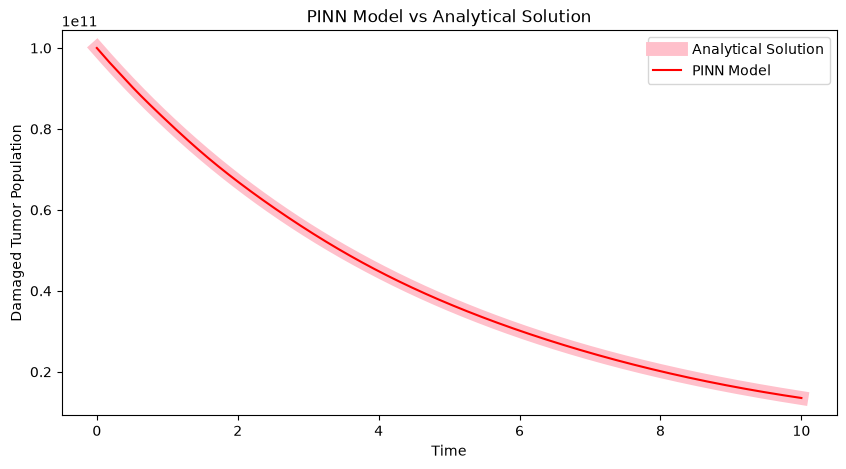

In [7]:
#Testing the Model
model.eval()
x_test = x.detach().clone().to(device=device, dtype=torch.float32)
y_pred_norm = model(x_test).detach().cpu().numpy().reshape(-1, 1)
y_pred_real = y_pred_norm * TD0_val

y_real = y_norm * TD0_val


#Plotting the Neural Network Model vs Analytical Solution
plt.figure(figsize=(10, 5))
plt.title("PINN Model vs Analytical Solution")
y = TD0 * exp(-delta_D * x)
plt.plot(x, y, label="Analytical Solution", color="pink", linewidth=10)
plt.xlabel("Time")
plt.ylabel("Damaged Tumor Population")

#plotting the analytical solution
plt.plot(x, y_pred_real, label="PINN Model", color="red")

#plotting the training data points
idx = np.arange(0, len(x), 100)
x_points = x[idx].numpy()
y_points = y_real[idx]
#plt.plot(x_points, y_points, label="Data Points", color="blue", linestyle="None", marker="o")
plt.legend()
plt.show()